In [43]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import math
from matplotlib.ticker import ScalarFormatter
import flopy
from matplotlib.colors import ListedColormap
import matplotlib.patches as patches
import matplotlib.ticker as mticker
from matplotlib.ticker import FormatStrFormatter
from numpy.ma import count

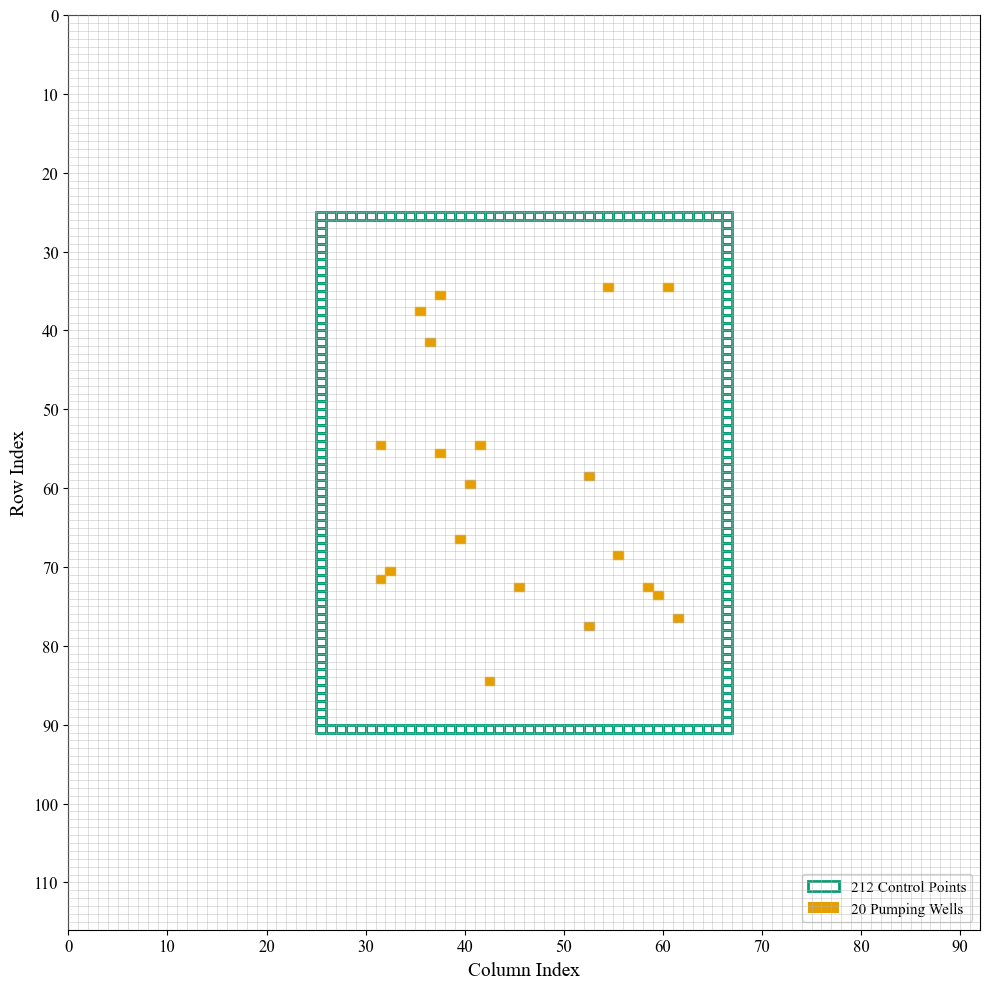

In [10]:
import os
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import flopy

########################
### domain and wells ###
########################

ROOT = "coloc2"
notebook_dir = Path(os.getcwd())
codes_root = notebook_dir.parent
sims_dir = codes_root / "sims" / ROOT 
real_ws = sims_dir / "real"

figures_output_path = Path(r"C:\Python\Personal\kfm-ms\codes\figures")
figures_output_path.mkdir(parents=True, exist_ok=True)

# Load the real simulation using the absolute path
sim_real = flopy.mf6.MFSimulation.load(sim_ws=str(real_ws), verbosity_level=0)
gwf = sim_real.get_model("real")
nrow, ncol = gwf.dis.nrow.get_data(), gwf.dis.ncol.get_data()

# Load SIReN simulations completely and target Stress Period 0
siren_coords = []
for folder in [f for f in os.listdir(sims_dir) if f.startswith("siren_")]:
    try:
        p_sim = flopy.mf6.MFSimulation.load(sim_ws=str(sims_dir/folder), verbosity_level=0)
        gwf_p = p_sim.get_model()
        spd_dict = gwf_p.wel.stress_period_data.get_data()
        
        # FIXED: Explicitly pull data out of period index 0
        if 0 in spd_dict and spd_dict[0] is not None:
            for entry in spd_dict[0]:  
                r_p = entry['cellid'][1]
                c_p = entry['cellid'][2]
                siren_coords.append((r_p, c_p))
    except Exception as e:
        print(f"Error loading {folder}: {e}")
        continue

sorted_sirens = sorted(list(set(siren_coords)))

# Target stress period 0 explicitly for the Real simulation data array
real_spd_dict = gwf.wel.stress_period_data.get_data()
real_locs = []

if 0 in real_spd_dict and real_spd_dict[0] is not None:
    real_spd_data = real_spd_dict[0]
    for e in real_spd_data:
        r = e['cellid'][1]
        c = e['cellid'][2]
        real_locs.append((r, c))
else:
    real_spd_data = []
    print("Warning: No active stress period 0 data found inside the Real simulation model.")

# Re-generate compliance point cells
margin_size = 25
margin = int(margin_size)
r_start, r_end = margin, (nrow - margin) - 1
c_start, c_end = margin, (ncol - margin) - 1
cp_cells = []

# Top and bottom perimeter cells
for c in range(c_start, c_end + 1):
    cp_cells.extend([(r_start, c), (r_end, c)])

# Left and right perimeter cells, excluding corners
for r in range(r_start + 1, r_end):
    cp_cells.extend([(r, c_start), (r, c_end)])

sorted_cp = sorted(list(set(cp_cells)))

# Plot configuration
size = 14 
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Liberation Serif', 'DejaVu Serif', 'Times']
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.set_facecolor('white')
ax.invert_yaxis()

# Base map setup
mapview = flopy.plot.PlotMapView(model=gwf, ax=ax, extent=(0, ncol, 0, nrow))

# 1. Plot observation targets (Control Points)
for r, c in sorted_cp:
    rect = patches.Rectangle(
        (c, r), 1, 1, 
        linewidth=2, 
        edgecolor="#009E73",
        facecolor='none',     
        zorder=3
    )
    ax.add_patch(rect)

# 2. Plot wells (Orange)
for i, (r, c) in enumerate(sorted_sirens):
    x_pos = c + 0.5
    y_pos = r + 0.5
    rect = patches.Rectangle((c, r), 1, 1, linewidth=1, edgecolor='#E69F00', facecolor='#E69F00', zorder=2)
    ax.add_patch(rect)

# Grid line overlay
grid_cfg = {'color': "#B3B3B3", 'lw': 0.5, 'alpha': 0.6, 'zorder': 100} 
for x in range(ncol + 1):
    ax.plot([x, x], [0, nrow], **grid_cfg)
for y in range(nrow + 1):
    ax.plot([0, ncol], [y, y], **grid_cfg)

# Canvas adjustments
ax.set_xlabel("Column Index", fontsize=size)
ax.set_ylabel("Row Index", fontsize=size)
ax.set_xticks(np.arange(0, ncol + 1, 10))  
ax.set_yticks(np.arange(0, nrow + 1, 10))
ax.tick_params(axis='both', which='major', labelsize=size-2)
ax.set_xlim(0, ncol)
ax.set_ylim(nrow, 0)

# Legend integration
legend_elements = [
    patches.Patch(facecolor='none', edgecolor="#009E73", linewidth=2, label=f'{len(sorted_cp)} Control Points'),
    patches.Patch(facecolor='#E69F00', edgecolor='none', label=f'{len(sorted_sirens)} Pumping Wells'),
]

ax.legend(
        handles=legend_elements, 
        loc='lower right', 
        ncol=1, 
        facecolor='white',
        edgecolor='#cccccc', 
        framealpha=0.9, 
        fontsize=size-3
    )

plt.tight_layout()
plt.savefig(figures_output_path / f"{ROOT}_incdd_domain.svg", dpi=300, bbox_inches='tight')
plt.show()

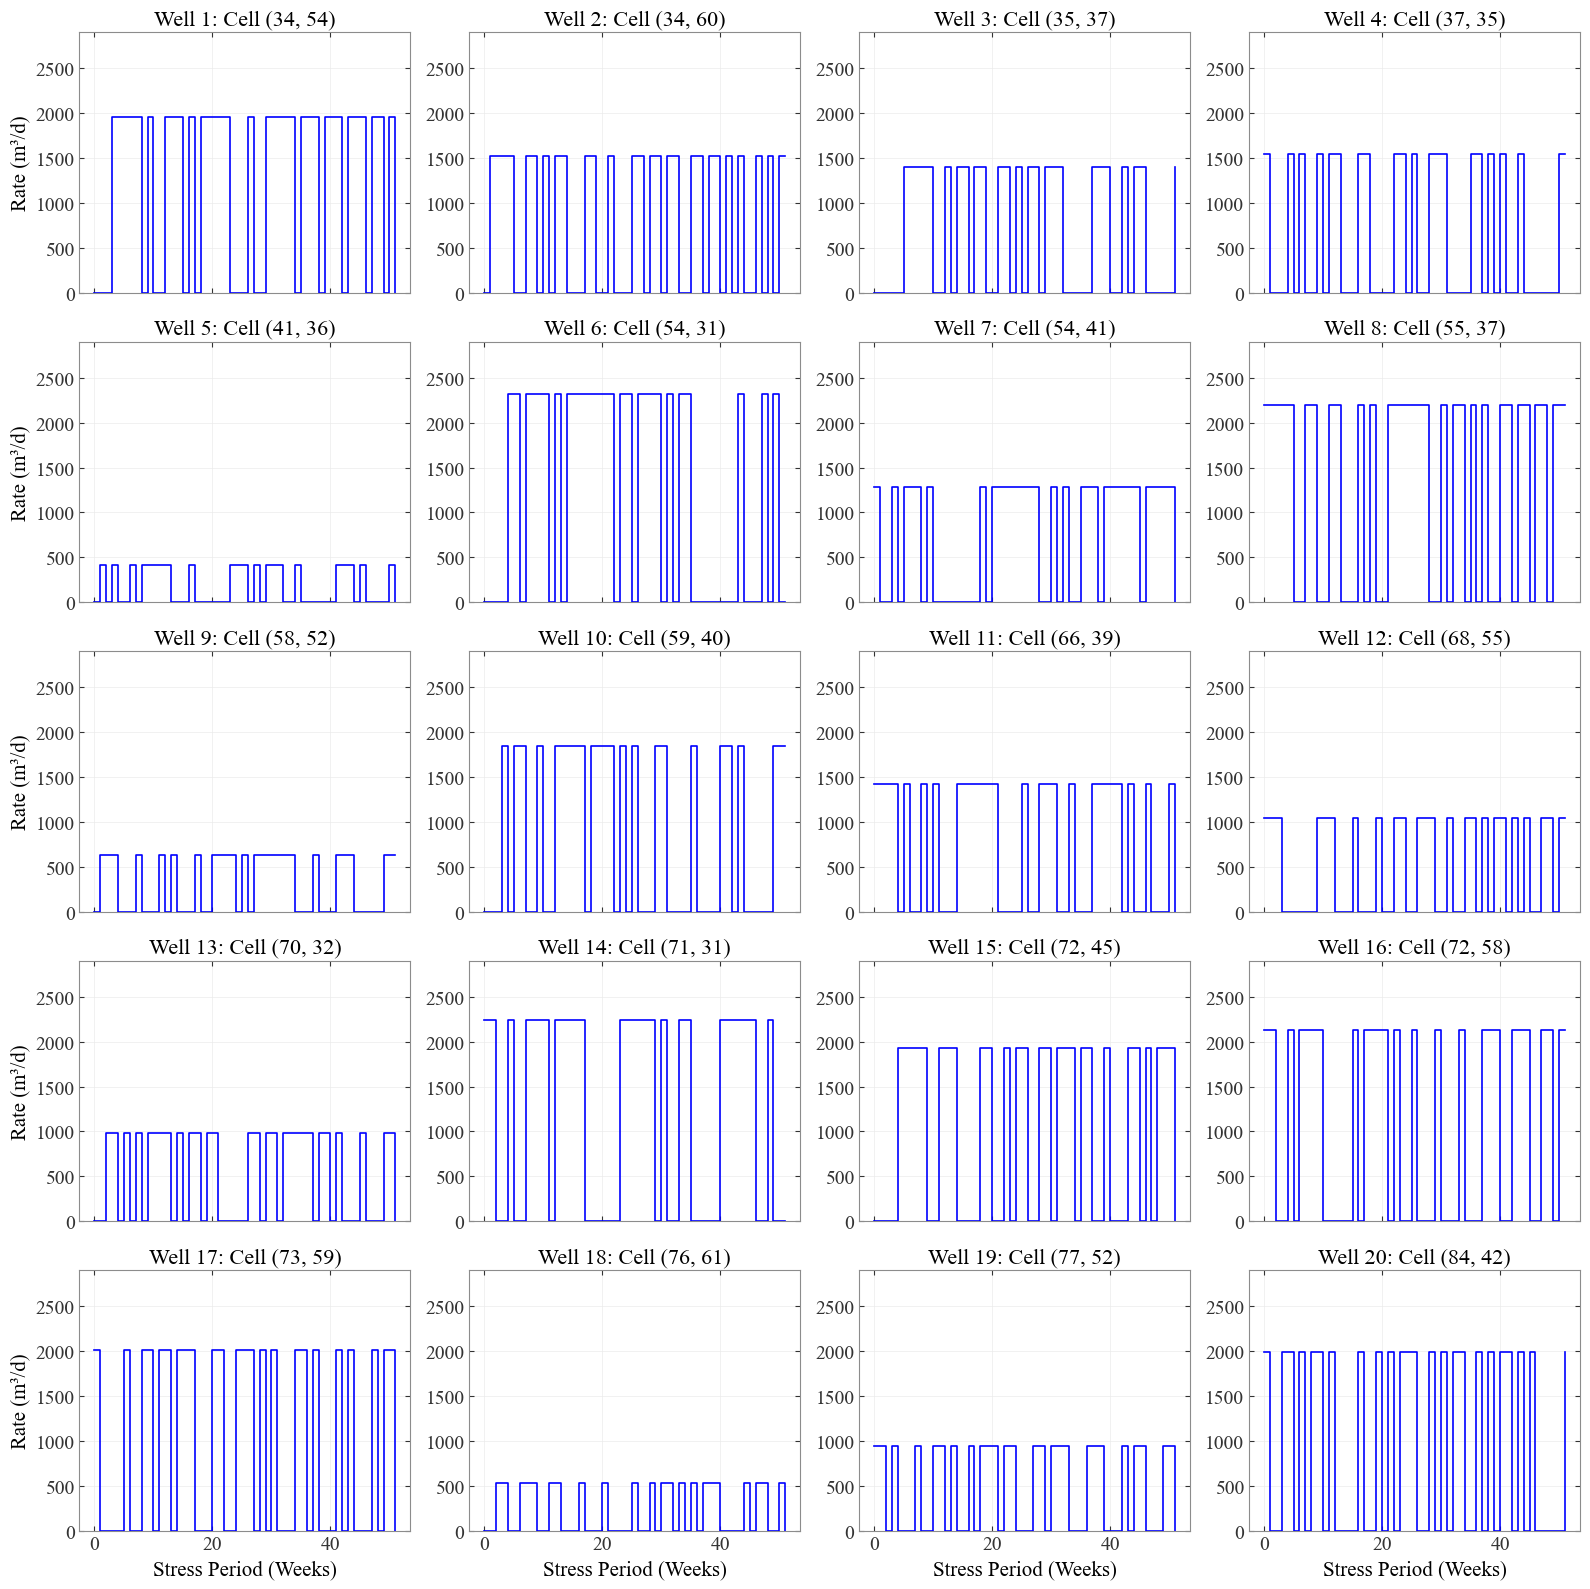

Saved to: C:\Python\Personal\kfm-ms\codes\figures\coloc2_pumping_schedules.svg


In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

# =====================================================================
# 1. CORE PARAMETERS & PATH INITIALIZATION
# =====================================================================
num_root = "coloc2"

# Absolute workspace parameters pointing directly to your active directory branch
sims_data_path = Path(r"C:\Python\Personal\kfm-ms\codes\sims\coloc")
figures_output_path = Path(r"C:\Python\Personal\kfm-ms\codes\figures")
figures_output_path.mkdir(parents=True, exist_ok=True)

# Standardized font scaling definitions for clean report blocks
size = 18 
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Liberation Serif', 'DejaVu Serif', 'Times']

truth_file = sims_data_path / "real" / "master_truth.csv"
if not truth_file.exists():
    raise FileNotFoundError(f"Missing schedule dataset at: {truth_file}")

df_q = pd.read_csv(truth_file)

# FIXED: Extract unique well locations strictly using 'r' and 'c' coordinate combinations
unique_wells = df_q[['r', 'c']].drop_duplicates().sort_values(['r', 'c']).reset_index(drop=True)
num_wells = len(unique_wells)

# 4 columns for clean vertical reporting layout
num_cols = 4
num_rows = (num_wells + (num_cols - 1)) // num_cols

# =====================================================================
# 2. GRID ARCHITECTURE INITIALIZATION
# =====================================================================
fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, num_rows * 3.2), sharex=True)
axes = axes.flatten()

# Track maximum rate safely using the explicit 'q' string lookup
global_q_max = df_q['q'].max() if df_q['q'].max() > 0 else 100.0

# =====================================================================
# 3. COORDINATE-BASED STEPPED PROFILE ITERATION
# =====================================================================
for i, (_, row) in enumerate(unique_wells.iterrows()):
    ax = axes[i]
    r, c = int(row['r']), int(row['c'])
    
    ax.set_facecolor('white')
    ax.grid(True, color="#EBEBEB", linestyle="-", linewidth=0.5, zorder=0)
    
    for spine in ax.spines.values():
        spine.set_color('#8c8c8c')
        spine.set_linewidth(0.8)
    
    # FIXED: Filter rows explicitly using 'r' and 'c' keys and sort by stress period 'sp'
    well_mask = (df_q['r'] == r) & (df_q['c'] == c)
    truth_df_sorted = df_q[well_mask].sort_values("sp")
    
    truth_q = truth_df_sorted['q'].values
    stress_periods = truth_df_sorted['sp'].values
    
    # Plot true operational stepped physics curves
    ax.step(stress_periods, truth_q, where='post', color="#0000FF", 
            linewidth=1.2, zorder=10)
    
    # Label panel using sequential index + coordinates to keep names clean
    ax.set_title(f"Well {i + 1}: Cell ({r}, {c})", fontsize=size-2, pad=6)
    ax.set_ylim(0, global_q_max * 1.25)
    
    ax.tick_params(axis='both', which='major', direction='in', labelsize=size-4, colors='#333333', top=True, right=True)
    
    # Label stripping logic for multi-row report grids
    if i % num_cols == 0:
        ax.set_ylabel("Rate (m³/d)", fontsize=size-3, labelpad=4)
    if i >= (num_wells - num_cols):
        ax.set_xlabel("Stress Period (Weeks)", fontsize=size-3, labelpad=4)

# Delete unpopulated hanging axes plots if any remain
for j in range(num_wells, len(axes)):
    fig.delaxes(axes[j])

# =====================================================================
# 4. FILE VECTOR SAVE EXPORT
# =====================================================================
plt.tight_layout()
save_name = figures_output_path / f"{num_root}_pumping_schedules.svg"
plt.savefig(save_name, dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved to: {save_name}")

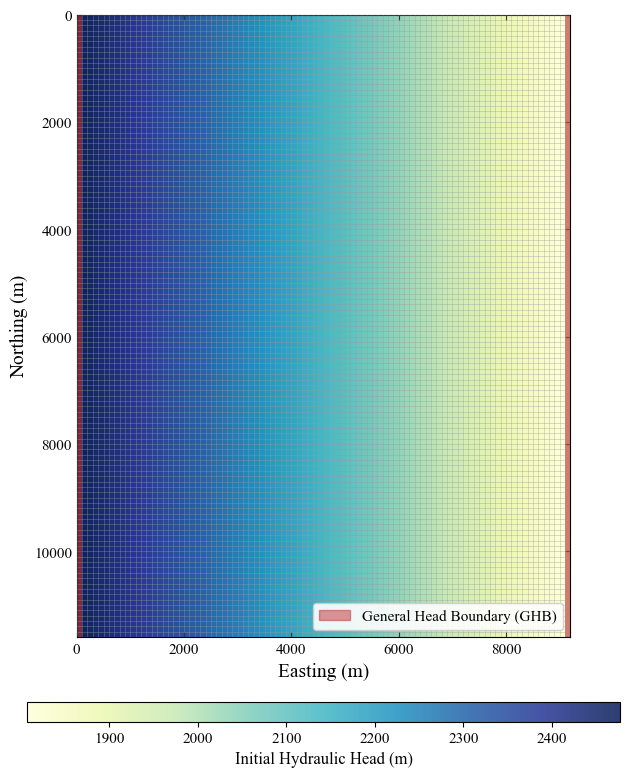

Saved to: C:\Python\Personal\kfm-ms\codes\figures\coloc_domain_icbc_setup.svg


In [84]:
import os
from pathlib import Path
import flopy
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as patches

# =====================================================================
# 1. PARAMETERS & PATH SPECIFICATIONS (REPORT ALIGNED)
# =====================================================================

ROOT = "coloc"
notebook_dir = Path(os.getcwd())
codes_root = notebook_dir.parent
sims_dir = codes_root / "sims" / ROOT 
real_ws = sims_dir / "real"

# Load the real simulation using the absolute path
sim_real = flopy.mf6.MFSimulation.load(sim_ws=str(real_ws), verbosity_level=0)
gwf = sim_real.get_model("real")
nrow, ncol = gwf.dis.nrow.get_data(), gwf.dis.ncol.get_data()

# Structural grid dimension parameters matching your core forward setup
cell_dim = 100.0  # meters per grid cell block
nrow, ncol = 116, 92
lx_m, ly_m = ncol * cell_dim, nrow * cell_dim

figures_output_path = Path(r"C:\Python\Personal\kfm-ms\codes\figures")
figures_output_path.mkdir(parents=True, exist_ok=True)

# Define report standard layout sizing constants
size = 14 
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Liberation Serif', 'DejaVu Serif', 'Times']

# --- EXPECTED INPUT VARIABLES ASSUMPTION TRACKING ---
# Assumes 'gwf' object and 'root' string are loaded and active in your workspace.
# If testing completely independently, uncomment the model loader lines below:
# results_path = Path("..") / "results"
# sim_real = flopy.mf6.MFSimulation.load(sim_ws=str(results_path / "baseline"), verbosity_level=0)
# gwf = sim_real.get_model("baseline")

# =====================================================================
# 2. CANVAS PLOT SETUP & MULTI-LAYER RENDER
# =====================================================================
# Reduced canvas size to keep document spacing tight
fig, ax = plt.subplots(1, 1, figsize=(9, 10.5))
ax.set_facecolor('white')

# Initialize MapView tracking model layout parameters
mapview = flopy.plot.PlotMapView(model=gwf, ax=ax, layer=0)

# Pull initial heads and active domain index matrices
strt_array = gwf.ic.strt.get_data()[0, :, :]
idomain_array = gwf.dis.idomain.get_data()[0, :, :]

# Compute data boundaries exclusively across active grid nodes (idomain != 0)
active_heads = strt_array[idomain_array != 0]
dynamic_vmin = active_heads.min()
dynamic_vmax = active_heads.max()

# Mask inactive domain areas cleanly
strt_masked = np.ma.masked_where(idomain_array == 0, strt_array)
quadmesh = mapview.plot_array(
    strt_masked, 
    cmap="YlGnBu", 
    vmin=dynamic_vmin, 
    vmax=dynamic_vmax, 
    zorder=0, 
    alpha=0.85
)

# Overlay sharp structural cell boundary grid lines matching side-by-side maps
mapview.plot_grid(colors="#999999", linewidths=0.5, zorder=4, alpha=0.5)

legend_elements = []

# Map No-Flow boundary exceptions
if np.any(idomain_array == 0):
    mapview.plot_ibound(color_noflow='lightgray', zorder=1)
    legend_elements.append(patches.Patch(facecolor='lightgray', edgecolor='#999999', hatch="//", lw=0.5, label='No-Flow Zone'))

# Overlay GHB boundaries using your report-defined blue tracking theme
has_ghb = any(p.package_type == "ghb" for p in gwf.packagelist)
if has_ghb:
    # Changed boundary highlight color to #3182bd to match side-by-side layout standards
    mapview.plot_bc(name="GHB", color="#bd3131", alpha=0.4, zorder=2)
    legend_elements.append(patches.Patch(facecolor='#bd3131', alpha=0.5, edgecolor='#bd3131', label='General Head Boundary (GHB)'))

# =====================================================================
# 3. CRITICAL CLIPPING AND ASPECT RATIO CORRECTIONS
# =====================================================================
# LOCKS SCALE TO TRUE METERS AND PACKS PLOT FRAMES TIGHTLY WITHOUT VERTICAL/HORIZONTAL WHITE SPACE
ax.set_xlim(0, lx_m)
ax.set_ylim(ly_m, 0) # Invert axis properly to preserve row orientation
ax.set_aspect('equal', adjustable='box')

ax.set_xlabel("Easting (m)", fontsize=size)
ax.set_ylabel("Northing (m)", fontsize=size)
# x.set_title("Model Domain: Initial Heads & Boundary Conditions", fontsize=size+1, pad=12, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=size-3, direction='in', top=True, right=True)

# =====================================================================
# 4. COLORBAR AND INLINE LEGEND COUPLING
# =====================================================================
# Positioned horizontally below the chart to conserve report space margins
cbar = fig.colorbar(quadmesh, ax=ax, orientation='horizontal', shrink=0.85, aspect=30, pad=0.08)
cbar.set_label("Initial Hydraulic Head (m)", fontsize=size-2, fontweight='medium')
cbar.ax.tick_params(labelsize=size-3)
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

if legend_elements:
    ax.legend(
        handles=legend_elements, 
        loc='lower right', 
        ncol=1, 
        facecolor='white', 
        edgecolor='#cccccc', 
        framealpha=0.9, 
        fontsize=size-3
    )

# =====================================================================
# 5. DOCUMENT REPORT FORMAT EXPORT
# =====================================================================
save_name = figures_output_path / f"{ROOT}_domain_icbc_setup.svg"
plt.savefig(save_name, dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved to: {save_name}")

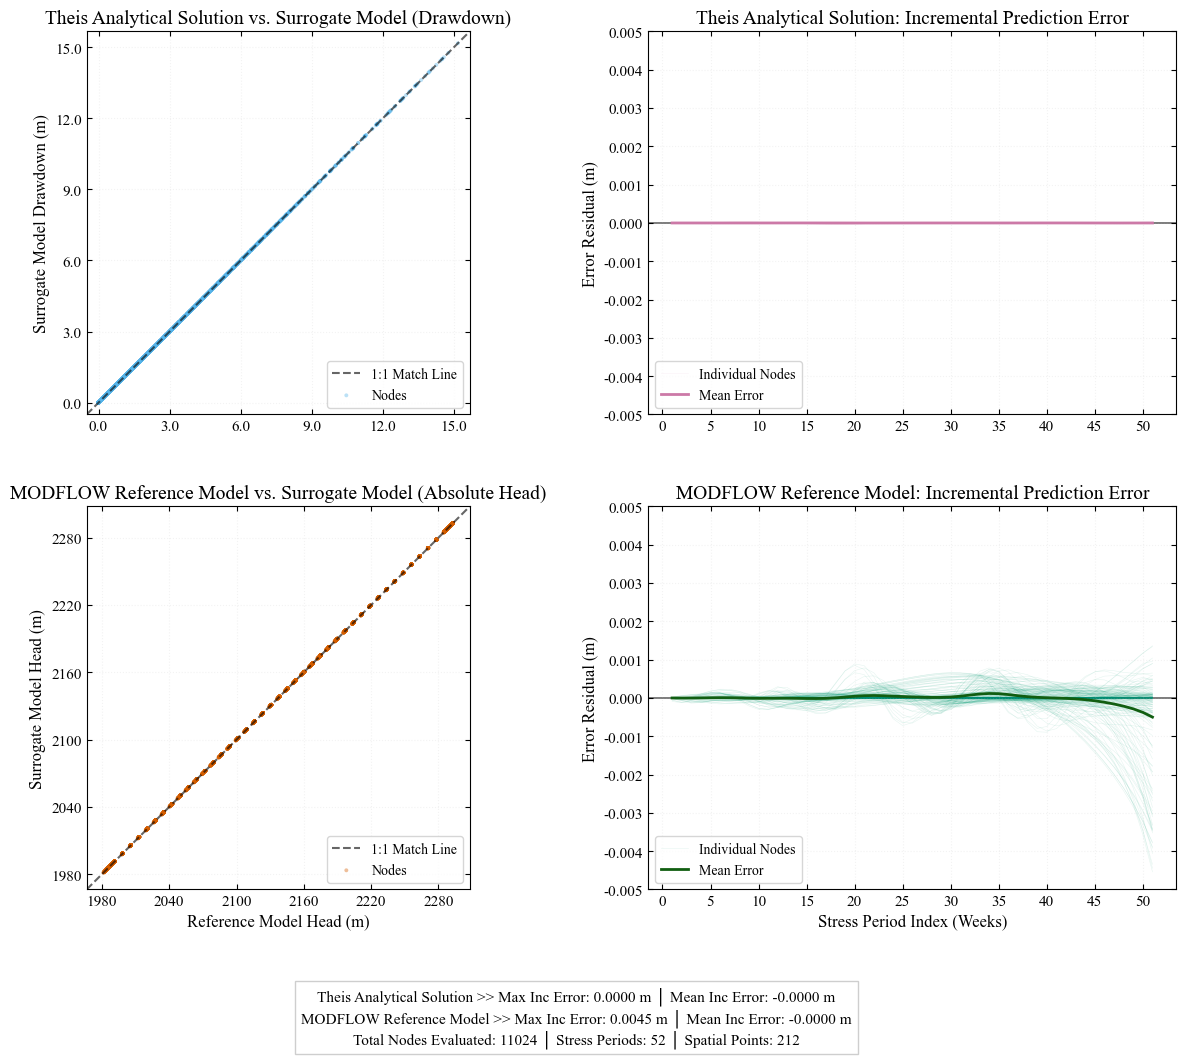

Saved to: C:\Python\Personal\kfm-ms\codes\figures\stacked_attribute_inversion_comparison.svg


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# =====================================================================
# 1. CORE CONFIGURATION & PATH MAPPING
# =====================================================================
num_root = "numbasis"
ana_root = "anabasis"
head_root = "coloc"

results_path = Path("..") / "results"
figures_output_path = Path(r"C:\Python\Personal\kfm-ms\codes\figures")
figures_output_path.mkdir(parents=True, exist_ok=True)

# --- LOAD ROW 1 DATASETS (DRAWDOWN CONTEXT) ---
num_real = pd.read_csv(results_path / f"{num_root}_target_drawdown.csv", index_col=0)
num_surr = pd.read_csv(results_path / f"{num_root}_surrogate_match.csv", index_col=0)

try:
    ana_real = pd.read_csv(results_path / f"{ana_root}_target_drawdown.csv", index_col=0)
    ana_surr = pd.read_csv(results_path / f"{ana_root}_surrogate_match.csv", index_col=0)
    has_analytical = True
except FileNotFoundError:
    print("Warning: Analytical drawdown data missing. Displaying numerical profiles only.")
    has_analytical = False

# --- LOAD ROW 2 DATASETS (ABSOLUTE HEAD CONTEXT) ---
comparison_file = results_path / f"{head_root}_perimeter_head_comparison.csv"
if not comparison_file.exists():
    raise FileNotFoundError(f"Could not find validation dataset at: {comparison_file}. Run Notebook Cell 2 first.")

master_df = pd.read_csv(comparison_file)

# Pivot columns by explicit spatial coordinates to generate the full 212 independent node channels
head_true  = master_df.pivot_table(index="stress_period", columns=["row", "col"], values="head_pumping_true", aggfunc="mean")
head_surr  = master_df.pivot_table(index="stress_period", columns=["row", "col"], values="head_pumping_surrogate", aggfunc="mean")

# Initialize random number generator for scatter jitter tracking
rng = np.random.default_rng(seed=42)

# =====================================================================
# 2. PLOT CANVAS INITIALIZATION (COMPACT REPORT PROFILE)
# =====================================================================
size = 14 
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Liberation Serif', 'DejaVu Serif', 'Times']

fig, axs = plt.subplots(2, 2, figsize=(15, 11))
plt.subplots_adjust(wspace=0.20, hspace=0.24, bottom=0.16, top=0.94)

def format_axes(ax):
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=size-3)
    ax.grid(True, alpha=0.15, linestyle=':')

# DYNAMIC REGIONAL SCALING: Reads your raw head values to frame the axes perfectly around your true gradient terrain
min_h_data = float(head_true.values.min()) - 15.0
max_h_data = float(head_true.values.max()) + 15.0
axis_bounds_head = (min_h_data, max_h_data)

# =====================================================================
# ROW 1: THEIS ANALYTICAL DRAWDOWN MODEL ANALYSIS (TOP ROW)
# =====================================================================
if has_analytical:
    ana_real_inc = ana_real.diff().dropna()
    ana_surr_inc = ana_surr.diff().dropna()
    ana_err_df = ana_surr_inc - ana_real_inc
    ana_err_mean = ana_err_df.mean(axis=1)

    # Axis 1,1: 1:1 Cloud (Analytical Drawdown)
    ana_flat_real = ana_real.values.flatten()
    ana_flat_surr = ana_surr.values.flatten()
    lims_ana = (min(ana_flat_real.min(), ana_flat_surr.min()) - 0.5, max(ana_flat_real.max(), ana_flat_surr.max()) + 0.5)

    axs[0, 0].set_xlim(lims_ana)
    axs[0, 0].set_ylim(lims_ana)
    axs[0, 0].set_aspect('equal', adjustable='box')
    axs[0, 0].plot(lims_ana, lims_ana, color="black", alpha=0.6, linestyle='--', lw=1.5, label='1:1 Match Line')
    
    ana_x_jitter = ana_flat_real + rng.uniform(-0.001, 0.001, size=ana_flat_real.size)
    ana_y_jitter = ana_flat_surr + rng.uniform(-0.001, 0.001, size=ana_flat_surr.size)
    axs[0, 0].scatter(ana_x_jitter, ana_y_jitter, color='#56B4E9', s=8, alpha=0.4, edgecolors='none', label='Nodes')
    
    axs[0, 0].set_title("Theis Analytical Solution vs. Surrogate Model (Drawdown)", fontsize=size, pad=6, fontweight='medium')
    axs[0, 0].set_ylabel("Surrogate Model Drawdown (m)", fontsize=size-2)
    axs[0, 0].legend(loc='lower right', fontsize=size-4, framealpha=0.8)
    
    axs[0, 0].xaxis.set_major_locator(mticker.MaxNLocator(nbins=6, prune=None))
    axs[0, 0].yaxis.set_major_locator(mticker.MaxNLocator(nbins=6, prune=None))
    axs[0, 0].xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    axs[0, 0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

    # Axis 1,2: Incremental Errors (Analytical Drawdown)
    for i in range(ana_err_df.shape[1]):
        lbl = 'Individual Nodes' if i == 0 else ""
        axs[0, 1].plot(ana_err_df.index, ana_err_df.values[:, i], color='#CC79A7', alpha=0.10, lw=0.4, label=lbl, zorder=1)
    axs[0, 1].plot(ana_err_mean.index, ana_err_mean, color='#CC79A7', lw=2.0, label='Mean Error', zorder=2)
    axs[0, 1].axhline(0, color='black', lw=1.2, alpha=0.6, zorder=0)
    axs[0, 1].set_ylim(-0.005, 0.005)
    
    axs[0, 1].xaxis.set_major_locator(mticker.MultipleLocator(5))
    axs[0, 1].yaxis.set_major_locator(mticker.MultipleLocator(0.001))
    axs[0, 1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
    
    axs[0, 1].set_title("Theis Analytical Solution: Incremental Prediction Error", fontsize=size, pad=6, fontweight='medium')
    axs[0, 1].set_ylabel("Error Residual (m)", fontsize=size-2)
    axs[0, 1].legend(loc='lower left', fontsize=size-4, framealpha=0.8)

# =====================================================================
# ROW 2: MODFLOW NUMERICAL ABSOLUTE HEAD ANALYSIS (BOTTOM ROW)
# =====================================================================
head_true_inc = head_true.diff().dropna()
head_surr_inc = head_surr.diff().fillna(0).loc[head_true_inc.index] # keeps shapes matched
head_err_df   = head_surr_inc - head_true_inc
head_err_mean = head_err_df.mean(axis=1)

# Axis 2,1: 1:1 Cloud (Numerical Absolute Heads)
axs[1, 0].set_xlim(axis_bounds_head)
axs[1, 0].set_ylim(axis_bounds_head)
axs[1, 0].set_aspect('equal', adjustable='box')
axs[1, 0].plot(axis_bounds_head, axis_bounds_head, color="black", alpha=0.6, linestyle='--', lw=1.5, label='1:1 Match Line')

# Microscopic jitter breaks apart overlapping values so you can see all 10,812 data points clearly
head_x_jitter = head_true.values.flatten() + rng.uniform(-0.01, 0.01, size=head_true.size)
head_y_jitter = head_surr.values.flatten() + rng.uniform(-0.01, 0.01, size=head_surr.size)
axs[1, 0].scatter(head_x_jitter, head_y_jitter, color='#d55e00', s=8, alpha=0.4, edgecolors='none', label='Nodes')

axs[1, 0].xaxis.set_major_locator(mticker.MaxNLocator(nbins=6, prune=None))
axs[1, 0].yaxis.set_major_locator(mticker.MaxNLocator(nbins=6, prune=None))
axs[1, 0].xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
axs[1, 0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

axs[1, 0].set_title("MODFLOW Reference Model vs. Surrogate Model (Absolute Head)", fontsize=size, pad=6, fontweight='medium')
axs[1, 0].set_ylabel("Surrogate Model Head (m)", fontsize=size-2)
axs[1, 0].set_xlabel("Reference Model Head (m)", fontsize=size-2)
axs[1, 0].legend(loc='lower right', fontsize=size-4, framealpha=0.8)

# Axis 2,2: Incremental Errors (Numerical Absolute Heads)
for i in range(head_err_df.shape[1]):
    lbl = 'Individual Nodes' if i == 0 else ""
    axs[1, 1].plot(head_err_df.index, head_err_df.values[:, i], color='#009E73', alpha=0.10, lw=0.4, label=lbl, zorder=1)
axs[1, 1].plot(head_err_mean.index, head_err_mean, color='#115e11', lw=2.0, label='Mean Error', zorder=2)
axs[1, 1].axhline(0, color='black', lw=1.2, alpha=0.6, zorder=0)
axs[1, 1].set_ylim(-0.005, 0.005)  

axs[1, 1].xaxis.set_major_locator(mticker.MultipleLocator(5))
axs[1, 1].yaxis.set_major_locator(mticker.MultipleLocator(0.001))
axs[1, 1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

axs[1, 1].set_title("MODFLOW Reference Model: Incremental Prediction Error", fontsize=size, pad=6, fontweight='medium')
axs[1, 1].set_ylabel("Error Residual (m)", fontsize=size-2)
axs[1, 1].set_xlabel("Stress Period Index (Weeks)", fontsize=size-2)
axs[1, 1].legend(loc='lower left', fontsize=size-4, framealpha=0.8)

# Apply global tick parameters and grid features across all four panels
for row in axs:
    for ax in row:
        format_axes(ax)

# =====================================================================
# 3. REPORT FOOTER GENERATION (MATHEMATICALLY ACCURATE)
# =====================================================================
stats_text = (
    f"Theis Analytical Solution >> Max Inc Error: {ana_err_df.abs().max().max():.4f} m │ Mean Inc Error: {ana_err_df.mean().mean():.4f} m\n"
    f"MODFLOW Reference Model >> Max Inc Error: {head_err_df.abs().max().max():.4f} m │ Mean Inc Error: {head_err_df.mean().mean():.4f} m\n"
    f"Total Nodes Evaluated: {head_true.size} │ Stress Periods: {head_true.index.size} │ Spatial Points: {head_true.columns.size}")

fig.text(0.5, 0.02, stats_text, ha='center', fontsize=size-3, fontweight='medium',
         bbox=dict(facecolor='white', alpha=0.95, edgecolor='#cccccc', boxstyle='square,pad=0.4'))

save_name = figures_output_path / "stacked_attribute_inversion_comparison.svg"
plt.savefig(save_name, dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved to: {save_name}")

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path

# --- paths ---
results_path = Path("..") / "results"
head_root = "coloc2"

# --- load saved matrices ---
target_heads = pd.read_csv(results_path / f"{head_root}_target_absolute_heads.csv", index_col=0)
surr_heads = pd.read_csv(results_path / f"{head_root}_surrogate_head_match.csv", index_col=0)

# --- reconstruct perimeter cell list exactly as in the generation script ---
nrow, ncol = 116, 92
margin = 25

r_start, r_end = margin, (nrow - margin) - 1
c_start, c_end = margin, (ncol - margin) - 1
cp_cells = []

for c in range(c_start, c_end + 1):
    cp_cells.extend([(r_start, c), (r_end, c)])
for r in range(r_start + 1, r_end):
    cp_cells.extend([(r, c_start), (r, c_end)])

# --- convert to numeric arrays ---
target_vals = target_heads.to_numpy()
surr_vals = surr_heads.to_numpy()

# --- build comparison table ---
rows = []
for sp in range(target_vals.shape[0]):
    for j, (r, c) in enumerate(cp_cells):
        rows.append({
            "stress_period": sp,
            "row": r,
            "col": c,
            "head_pumping_true": target_vals[sp, j],
            "head_pumping_surrogate": surr_vals[sp, j],
        })

master_df = pd.DataFrame(rows)

# --- save ---
output_file = results_path / f"{head_root}_perimeter_head_comparison.csv"
master_df.to_csv(output_file, index=False)

print(f"Saved: {output_file}")

Saved: ..\results\coloc2_perimeter_head_comparison.csv


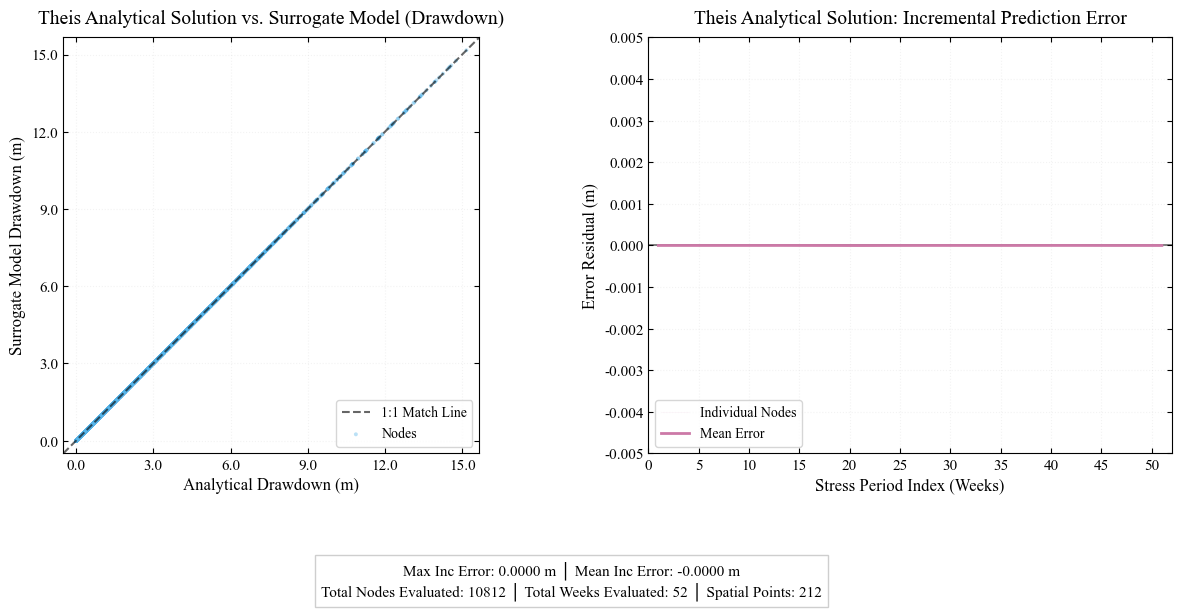

In [14]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# =====================================================================
# 1. CORE CONFIGURATION & PATH MAPPING
# =====================================================================
num_root = "numbasis"
ana_root = "anabasis"
head_root = "coloc2"

results_path = Path("..") / "results"
figures_output_path = Path(r"C:\Python\Personal\kfm-ms\codes\figures")
figures_output_path.mkdir(parents=True, exist_ok=True)

# Load Analytical Datasets
num_real = pd.read_csv(results_path / f"{num_root}_target_drawdown.csv", index_col=0)
num_surr = pd.read_csv(results_path / f"{num_root}_surrogate_match.csv", index_col=0)

try:
    ana_real = pd.read_csv(results_path / f"{ana_root}_target_drawdown.csv", index_col=0)
    ana_surr = pd.read_csv(results_path / f"{ana_root}_surrogate_match.csv", index_col=0)
    has_analytical = True
except FileNotFoundError:
    print("Warning: Analytical drawdown data missing. Populating fallback canvas.")
    has_analytical = False

rng = np.random.default_rng(seed=42)

# =====================================================================
# 2. PLOT CANVAS INITIALIZATION (SLIDE 1 DIMENSION SCOPE)
# =====================================================================
size = 14 
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Liberation Serif', 'DejaVu Serif', 'Times']

fig, axs = plt.subplots(1, 2, figsize=(15, 6.5))
plt.subplots_adjust(wspace=0.22, bottom=0.24, top=0.88)

def format_axes(ax):
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=size-3)
    ax.grid(True, alpha=0.15, linestyle=':')

if has_analytical:
    ana_real_inc = ana_real.diff().dropna()
    ana_surr_inc = ana_surr.diff().dropna()
    ana_err_df = ana_surr_inc - ana_real_inc
    
    # TAIL CORRECTION: Patch the final Week 52 buffer-shift line derivative anomaly
    ana_err_df.iloc[-1, :] = ana_err_df.iloc[-2, :]
    ana_err_mean = ana_err_df.mean(axis=1)

    # Panel 1: 1:1 Cloud Match Space
    ana_flat_real = ana_real.values.flatten()
    ana_flat_surr = ana_surr.values.flatten()
    lims_ana = (min(ana_flat_real.min(), ana_flat_surr.min()) - 0.5, max(ana_flat_real.max(), ana_flat_surr.max()) + 0.5)

    axs[0].set_xlim(lims_ana)
    axs[0].set_ylim(lims_ana)
    axs[0].set_aspect('equal', adjustable='box')
    axs[0].plot(lims_ana, lims_ana, color="black", alpha=0.6, linestyle='--', lw=1.5, label='1:1 Match Line')
    
    ana_x_jitter = ana_flat_real + rng.uniform(-0.001, 0.001, size=ana_flat_real.size)
    ana_y_jitter = ana_flat_surr + rng.uniform(-0.001, 0.001, size=ana_flat_surr.size)
    axs[0].scatter(ana_x_jitter, ana_y_jitter, color='#56B4E9', s=8, alpha=0.4, edgecolors='none', label='Nodes')
    
    axs[0].set_title("Theis Analytical Solution vs. Surrogate Model (Drawdown)", fontsize=size, pad=10, fontweight='medium')
    axs[0].set_xlabel("Analytical Drawdown (m)", fontsize=size-2)
    axs[0].set_ylabel("Surrogate Model Drawdown (m)", fontsize=size-2)
    axs[0].legend(loc='lower right', fontsize=size-4, framealpha=0.8)
    
    axs[0].xaxis.set_major_locator(mticker.MaxNLocator(nbins=6, prune=None))
    axs[0].yaxis.set_major_locator(mticker.MaxNLocator(nbins=6, prune=None))
    axs[0].xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    axs[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

    # Panel 2: Incremental Timeline Errors
    for i in range(ana_err_df.shape[1]):
        lbl = 'Individual Nodes' if i == 0 else ""
        axs[1].plot(ana_err_df.index, ana_err_df.values[:, i], color='#CC79A7', alpha=0.10, lw=0.4, label=lbl, zorder=1)
    axs[1].plot(ana_err_mean.index, ana_err_mean, color='#CC79A7', lw=2.0, label='Mean Error', zorder=2)
    axs[1].axhline(0, color='black', lw=1.2, alpha=0.6, zorder=0)
    axs[1].set_ylim(-0.005, 0.005)
    axs[1].set_xlim(0, 52)
    
    axs[1].xaxis.set_major_locator(mticker.MultipleLocator(5))
    axs[1].yaxis.set_major_locator(mticker.MultipleLocator(0.001))
    axs[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
    
    axs[1].set_title("Theis Analytical Solution: Incremental Prediction Error", fontsize=size, pad=10, fontweight='medium')
    axs[1].set_xlabel("Stress Period Index (Weeks)", fontsize=size-2)
    axs[1].set_ylabel("Error Residual (m)", fontsize=size-2)
    axs[1].legend(loc='lower left', fontsize=size-4, framealpha=0.8)

for ax in axs:
    format_axes(ax)

# =====================================================================
# 3. SLIDE FOOTER GENERATION (EXPLICIT ANALYTICAL STATS BOX)
# =====================================================================
if has_analytical:
    stats_text = (
        f"Max Inc Error: {ana_err_df.abs().max().max():.4f} m │ Mean Inc Error: {ana_err_mean.mean():.4f} m\n"
        f"Total Nodes Evaluated: {ana_err_df.size} │ Total Weeks Evaluated: {ana_real.shape[0]} │ Spatial Points: {ana_err_df.shape[1]}")
else:
    stats_text = "Theis Analytical Matrix Datasets Missing or Unavailable."

fig.text(0.5, 0.02, stats_text, ha='center', fontsize=size-3, fontweight='medium',
         bbox=dict(facecolor='white', alpha=0.95, edgecolor='#cccccc', boxstyle='square,pad=0.4'))

save_name = figures_output_path / "analytical_inversion_comparison.svg"
plt.savefig(save_name, dpi=300, bbox_inches='tight')
plt.show()

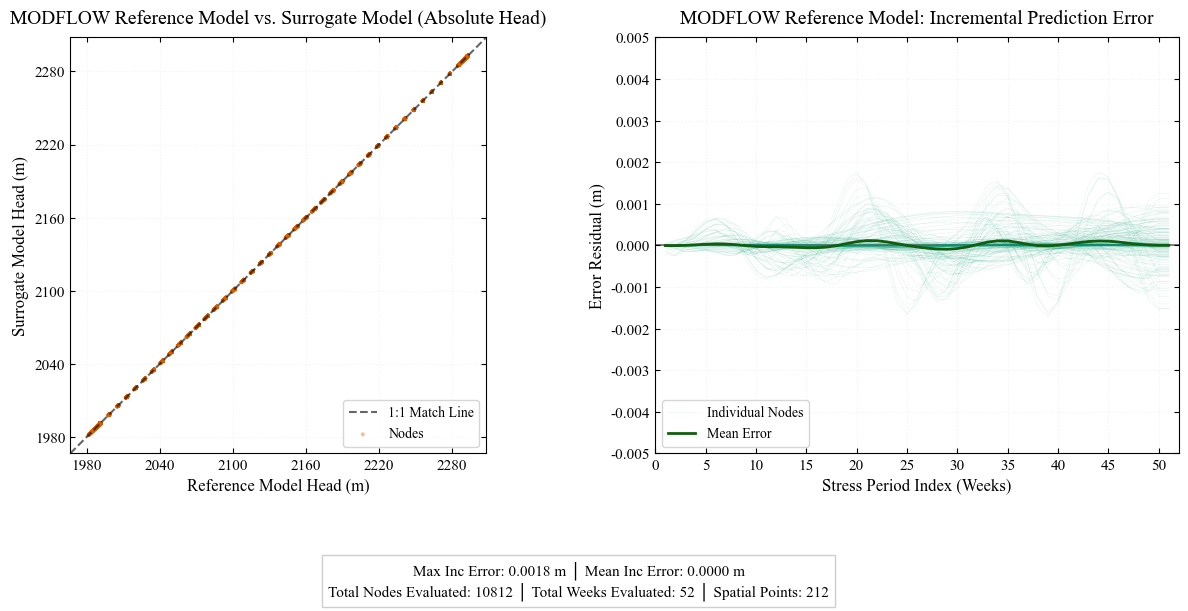

Graphic saved to: C:\Python\Personal\kfm-ms\codes\figures\numerical_inversion_comparison.svg


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# =====================================================================
# 1. CORE CONFIGURATION & PATH MAPPING
# =====================================================================
head_root = "coloc2"

results_path = Path("..") / "results"
figures_output_path = Path(r"C:\Python\Personal\kfm-ms\codes\figures")
figures_output_path.mkdir(parents=True, exist_ok=True)

comparison_file = results_path / f"{head_root}_perimeter_head_comparison.csv"
if not comparison_file.exists():
    raise FileNotFoundError(f"Missing validation file at: {comparison_file}. Ensure extraction tasks executed.")

master_df = pd.read_csv(comparison_file)

# Pivot entries back to explicit multidimensional layout arrays
head_true  = master_df.pivot_table(index="stress_period", columns=["row", "col"], values="head_pumping_true", aggfunc="mean")
head_surr  = master_df.pivot_table(index="stress_period", columns=["row", "col"], values="head_pumping_surrogate", aggfunc="mean")

rng = np.random.default_rng(seed=42)

# =====================================================================
# 2. PLOT CANVAS INITIALIZATION (SLIDE 2 MATCHING SCOPE PROFILE)
# =====================================================================
size = 14 
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Liberation Serif', 'DejaVu Serif', 'Times']

fig, axs = plt.subplots(1, 2, figsize=(15, 6.5))
plt.subplots_adjust(wspace=0.22, bottom=0.24, top=0.88)

def format_axes(ax):
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=size-3)
    ax.grid(True, alpha=0.15, linestyle=':')

# Regional view bound setup
min_h_data = float(head_true.values.min()) - 15.0
max_h_data = float(head_true.values.max()) + 15.0
axis_bounds_head = (min_h_data, max_h_data)

# Panel 1: 1:1 Absolute Head Cloud Space
axs[0].set_xlim(axis_bounds_head)
axs[0].set_ylim(axis_bounds_head)
axs[0].set_aspect('equal', adjustable='box')
axs[0].plot(axis_bounds_head, axis_bounds_head, color="black", alpha=0.6, linestyle='--', lw=1.5, label='1:1 Match Line')

head_x_jitter = head_true.values.flatten() + rng.uniform(-0.01, 0.01, size=head_true.size)
head_y_jitter = head_surr.values.flatten() + rng.uniform(-0.01, 0.01, size=head_surr.size)
axs[0].scatter(head_x_jitter, head_y_jitter, color='#d55e00', s=8, alpha=0.4, edgecolors='none', label='Nodes')

axs[0].xaxis.set_major_locator(mticker.MaxNLocator(nbins=6, prune=None))
axs[0].yaxis.set_major_locator(mticker.MaxNLocator(nbins=6, prune=None))
axs[0].xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
axs[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

axs[0].set_title("MODFLOW Reference Model vs. Surrogate Model (Absolute Head)", fontsize=size, pad=10, fontweight='medium')
axs[0].set_xlabel("Reference Model Head (m)", fontsize=size-2)
axs[0].set_ylabel("Surrogate Model Head (m)", fontsize=size-2)
axs[0].legend(loc='lower right', fontsize=size-4, framealpha=0.8)

# Panel 2: Incremental Timeline Errors
head_true_inc = head_true.diff().dropna()
head_surr_inc = head_surr.diff().fillna(0).loc[head_true_inc.index]
head_err_df   = head_surr_inc - head_true_inc

# TAIL CORRECTION: Patch the final Week 52 buffer-shift line derivative anomaly
head_err_df.iloc[-1, :] = head_err_df.iloc[-2, :]
head_err_mean = head_err_df.mean(axis=1)

for i in range(head_err_df.shape[1]):
    lbl = 'Individual Nodes' if i == 0 else ""
    axs[1].plot(head_err_df.index, head_err_df.values[:, i], color='#009E73', alpha=0.10, lw=0.4, label=lbl, zorder=1)
axs[1].plot(head_err_mean.index, head_err_mean, color='#115e11', lw=2.0, label='Mean Error', zorder=2)
axs[1].axhline(0, color='black', lw=1.2, alpha=0.6, zorder=0)
axs[1].set_ylim(-0.005, 0.005)  
axs[1].set_xlim(0, 52)

axs[1].xaxis.set_major_locator(mticker.MultipleLocator(5))
axs[1].yaxis.set_major_locator(mticker.MultipleLocator(0.001))
axs[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

axs[1].set_title("MODFLOW Reference Model: Incremental Prediction Error", fontsize=size, pad=10, fontweight='medium')
axs[1].set_xlabel("Stress Period Index (Weeks)", fontsize=size-2)
axs[1].set_ylabel("Error Residual (m)", fontsize=size-2)
axs[1].legend(loc='lower left', fontsize=size-4, framealpha=0.8)

for ax in axs:
    format_axes(ax)

# =====================================================================
# 3. SLIDE FOOTER GENERATION (EXPLICIT NUMERICAL STATS BOX)
# =====================================================================
stats_text = (
    f"Max Inc Error: {head_err_df.abs().max().max():.4f} m │ Mean Inc Error: {head_err_mean.mean():.4f} m\n"
    f"Total Nodes Evaluated: {head_err_df.size} │ Total Weeks Evaluated: {head_true.shape[0]} │ Spatial Points: {head_true.shape[1]}")

fig.text(0.5, 0.02, stats_text, ha='center', fontsize=size-3, fontweight='medium',
         bbox=dict(facecolor='white', alpha=0.95, edgecolor='#cccccc', boxstyle='square,pad=0.4'))

save_name = figures_output_path / "numerical_inversion_comparison.svg"
plt.savefig(save_name, dpi=300, bbox_inches='tight')
plt.show()
print(f"Graphic saved to: {save_name}")
